# Entregável 8 — Redução de Dimensionalidade

**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Ferreira Lessa & Matheus Rocha Gomes da Silva  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.  
**Data:** Abril e Maio de 2026

---

## Objetivo

Este notebook realiza a **Redução de Dimensionalidade** sobre o dataset engenhado produzido no Entregável 7 (`features_engineered.parquet`), com dois objetivos distintos e complementares:

1. **Compressão para classificação:** reduzir o vetor de features a um conjunto menor de componentes que retém a estrutura informativa do dataset, aliviando a maldição da dimensionalidade e reduzindo o custo computacional dos classificadores no Entregável de RP.

2. **Análise exploratória da estrutura latente:** identificar se as superclasses diagnósticas formam agrupamentos coerentes no espaço reduzido, validando a qualidade do pipeline de extração e engenharia de features antes da classificação formal.

As técnicas aplicadas são:

* **PCA (Principal Component Analysis):** decompõe o dataset em direções ortogonais de máxima variância, ordenadas por variância explicada. É o método de referência para redução linear de dimensionalidade e produz o artefato principal deste entregável (`features_pca.parquet`).
* **ICA (Independent Component Analysis):** busca componentes estatisticamente independentes em vez de apenas descorrelacionados. Aplicado sobre os primeiros componentes PCA, investiga se algum componente independente captura predominantemente variância de qualidade de sinal (artefato residual), o que permitiria descartá-lo seletivamente.

Este entregável é dividido em:

1. **Diagnóstico de Dimensionalidade:** avaliação da redundância e justificativa para aplicação de técnicas de redução ($\frac{F}{\sqrt{N}}$, correlação entre features).
2. **Análise com PCA:** decomposição, escolha do número de componentes, interpretação fisiológica (loadings) e validação por reconstrução.
3. **Análise com ICA:** extração de componentes independentes no espaço PCA e avaliação de relevância (ANOVA e não-gaussianidade).
4. **Persistência e Síntese:** salvamento dos artefatos gerados e consolidação das principais conclusões do entregável.

> **Nota sobre o pipeline:** o `features_pca.parquet` é uma representação alternativa para classificadores que operam em espaço comprimido (kNN, SVM com kernel linear). O Entregável 9 (Seleção de Atributos) opera em paralelo sobre o `features_engineered.parquet`, mantendo a interpretabilidade clínica das features originais.


## 1. Importações, Configurações e Dependências

Bibliotecas específicas deste notebook:

- **`sklearn.decomposition.PCA`:** implementação via SVD truncado. O parâmetro `n_components=None` calcula todos os componentes, permitindo a análise completa da variância antes de definir o corte.
- **`sklearn.decomposition.FastICA`:** algoritmo FastICA (Hyvärinen & Oja, 2000) para separação de fontes independentes. Usa o critério de neguentropia para maximizar a não-gaussianidade dos componentes.
- **`matplotlib.patches.Ellipse` / `matplotlib.transforms`:** para construção das elipses de confiança nas projeções 2D.

In [47]:
import os
import ast
import gc
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import seaborn as sns
from pathlib import Path
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
from sklearn.decomposition import PCA, FastICA
from matplotlib.patches import Ellipse
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

## 2. Configurações Globais e Carregamento

In [48]:
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL     = 9
FOLD_TEST    = 10

DIR_IN_D7 = Path('../../entregavel-7/outputs/')
FIGS_DIR  = Path('../figuras/')
OUT_DIR   = Path('../outputs/')

for d in [FIGS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

META_COLS = ['ecg_id', 'patient_id', 'strat_fold', 'quality_class',
             'superclasses_clean', 'primary_class', 'n_superclasses', 'split']

parquet_path = DIR_IN_D7 / 'features_engineered.parquet'
if not parquet_path.exists():
    raise FileNotFoundError(
        f'Arquivo nao encontrado: {parquet_path}\n'
        'Execute o Entregavel 7 antes de prosseguir.'
    )

print('Carregando features engenhadas do Entregavel 7...')
df = pd.read_parquet(str(parquet_path))

if 'superclasses_clean' in df.columns and isinstance(df['superclasses_clean'].iloc[0], str):
    df['superclasses_clean'] = df['superclasses_clean'].apply(ast.literal_eval)

if 'primary_class' not in df.columns:
    df['primary_class'] = df['superclasses_clean'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 'UNKNOWN'
    )

META_COLS    = [c for c in META_COLS if c in df.columns]
feature_cols = [c for c in df.columns if c not in META_COLS]
mask_treino  = df['strat_fold'].isin(FOLDS_TREINO)

print(f'Dataset carregado   : {df.shape}')
print(f'Features            : {len(feature_cols)}')
print(f'Registros de treino : {mask_treino.sum()}')
print(f'Registros totais    : {len(df)}')

Carregando features engenhadas do Entregavel 7...
Dataset carregado   : (17744, 289)
Features            : 282
Registros de treino : 14241
Registros totais    : 17744


---

## Seção 1 — Diagnóstico de Dimensionalidade e Motivação

### 1.1 A Maldição da Dimensionalidade no Contexto do ECG

O dataset produzido no Entregável 7 contém centenas de features distribuídas em cinco domínios de análise. Apesar da riqueza dessa representação, um número excessivo de features em relação ao número de amostras gera problemas concretos para os classificadores do Entregável de RP:

- **Algoritmos baseados em distância (kNN, SVM-RBF):** em espaços de alta dimensão, as distâncias euclidianas entre todos os pares de pontos tendem a convergir para o mesmo valor — o conceito de "vizinho próximo" perde significado. Isso é formalmente descrito como a **concentração de medida** em altas dimensões.
- **Overfitting:** com muitas features, o classificador tem maior liberdade para memorizar o conjunto de treino em vez de aprender padrões generalizáveis. O risco cresce especialmente quando `n_features >> sqrt(n_amostras)`.
- **Custo computacional:** algoritmos como SVM têm complexidade que escala com o número de features, tornando o treinamento custoso sem redução prévia.
- **Redundância estrutural:** como demonstrado no Entregável 7, parte das features são altamente correlacionadas entre si. Features correlacionadas não adicionam informação nova mas aumentam custo e instabilidade numérica.

A regra prática `n_features > sqrt(n_amostras)` é um indicador heurístico amplamente usado para sinalizar quando a redução de dimensionalidade é recomendada.

In [49]:
# Função simples de diagnóstico de n_features > sqrt(n_amostras)

n_samples  = df.shape[0]
n_features = len(feature_cols)
sqrt_n     = np.sqrt(n_samples)
razao      = n_features / sqrt_n

display(pd.DataFrame({
    'Metrica'    : ['N de Registros (N)', 'N de Features (F)',
                    'sqrt(N) (referencia heuristica)', 'Razao F / sqrt(N)'],
    'Valor'      : [n_samples, n_features, round(sqrt_n, 1), round(razao, 2)],
    'Referencia' : ['—', '—', '—',
                    '< 1.0: baixo risco  |  > 1.0: reducao recomendada']
}))

status = 'REDUCAO ALTAMENTE RECOMENDADA' if razao > 1 else 'Dimensionalidade sob controle'
print(f'\nDiagnostico: {status}')
print(f'O dataset tem {razao:.1f}x mais features que o limiar heuristico.')

,Metrica,Valor,Referencia
0,N de Registros (N),17744.00,—
1,N de Features (F),282.00,—
2,sqrt(N) (referencia heuristica),133.20,—
3,Razao F / sqrt(N),2.12,< 1.0: baixo risco | > 1.0: reducao recomendada



Diagnostico: REDUCAO ALTAMENTE RECOMENDADA
O dataset tem 2.1x mais features que o limiar heuristico.


### 1.2 Correlação Média entre Features — Evidência de Redundância

Além da heurística de dimensionalidade, a correlação média entre features quantifica diretamente o grau de redundância do dataset. Uma correlação média alta indica que o PCA vai conseguir comprimir bastante o espaço com poucos componentes, porque grande parte da variância das features está concentrada em poucas direções.

In [50]:
# Calcula correlacao de Pearson sobre amostra do treino para eficiência

amostra_idx = df[mask_treino].sample(min(15000, mask_treino.sum()), random_state=42).index
corr_matrix = df.loc[amostra_idx, feature_cols].corr(method='pearson').values

tri_upper    = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
corr_media   = np.mean(np.abs(tri_upper))
pct_alta_cor = np.mean(np.abs(tri_upper) > 0.70) * 100

print(f'Correlacao media absoluta entre features : {corr_media:.3f}')
print(f'Pares com |r| > 0.70                     : {pct_alta_cor:.1f}% dos pares')
print()
if corr_media > 0.3:
    print('Correlacao media elevada — PCA deve comprimir eficientemente com poucos componentes.')
else:
    print('Correlacao media baixa — PCA pode precisar de mais componentes para reter 95% da variancia.')

Correlacao media absoluta entre features : 0.209
Pares com |r| > 0.70                     : 2.8% dos pares

Correlacao media baixa — PCA pode precisar de mais componentes para reter 95% da variancia.


---

## Seção 2 — PCA (Principal Component Analysis)

### 2.1 Fundamentação

O PCA é uma transformação linear que projeta o dataset em um novo sistema de coordenadas onde:

1. **Os eixos (componentes principais) são ortogonais entre si** — os componentes são descorrelacionados por construção.
2. **O primeiro componente captura a direção de máxima variância**, o segundo captura a máxima variância residual ortogonal ao primeiro, e assim sucessivamente.
3. **Os componentes são ordenados por variância decrescente** — os primeiros $k$ componentes retêm mais variância que qualquer outro subconjunto de $k$ direções ortogonais.

Matematicamente, o PCA resolve o problema de autovalores da matriz de covariância $\Sigma$:

$$\Sigma v_i = \lambda_i v_i$$

onde $\lambda_i$ é o autovalor (variância explicada pelo componente $i$) e $v_i$ é o autovetor correspondente — o **loading** desse componente sobre as features originais.

### 2.2 Padronização

**Por que standardizar antes do PCA?**

O dataset já foi escalonado com `RobustScaler` no Entregável 7. Aplicamos um `StandardScaler` adicional aqui para garantir variância exatamente unitária por feature antes do PCA — o RobustScaler centraliza pela mediana e divide pelo IQR, o que não garante variância = 1. Se features com variâncias diferentes entrassem no PCA diretamente, os componentes seriam dominados pelas de maior variância absoluta, independentemente de relevância diagnóstica.

**Regra de ouro: fit apenas no treino.** O `StandardScaler` e o `PCA` são fitados exclusivamente nos folds 1–8 e depois aplicados a todo o dataset via `transform`.

In [51]:
# Aplicação de StandardScaler

X_treino = df.loc[mask_treino, feature_cols].values
X_todos  = df[feature_cols].values

print('Ajustando StandardScaler nos folds 1-8...')
scaler_pca   = StandardScaler()
X_treino_std = scaler_pca.fit_transform(X_treino)
X_todos_std  = scaler_pca.transform(X_todos)

print(f'Shape treino padronizado : {X_treino_std.shape}')
print(f'Shape total padronizado  : {X_todos_std.shape}')
print(f'Media das colunas (treino) = {X_treino_std.mean(axis=0).mean():.4f}  (esperado = 0)')
print(f'Std das colunas (treino)   = {X_treino_std.std(axis=0).mean():.4f}  (esperado = 1)')

Ajustando StandardScaler nos folds 1-8...
Shape treino padronizado : (14241, 282)
Shape total padronizado  : (17744, 282)
Media das colunas (treino) = 0.0000  (esperado = 0)
Std das colunas (treino)   = 1.0000  (esperado = 1)


### 2.3 Ajuste do PCA Completo e Análise de Variância

Realizamos primeiro o PCA com todos os componentes (`n_components=None`) para entender a distribuição de variância antes de definir o corte. Dois critérios são avaliados:

- **Critério de Kaiser:** mantém componentes cuja variância explicada é acima da média (equivalente ao critério clássico de autovalor > 1 quando as features têm variância unitária). É um critério conservador que tende a selecionar menos componentes.
- **Critério de variância acumulada:** mantém o menor número de componentes que juntos retêm um limiar de variância (80%, 90%, **95%**, 99%). O limiar de **95%** é o padrão adotado neste trabalho, equilibrando compressão e preservação de informação.

O **Scree Plot** visualiza a variância explicada por cada componente em ordem decrescente. O ponto de inflexão da curva — onde o decaimento passa de abrupto para gradual — sugere o número "natural" de componentes informativos.

In [52]:
# PCA

print('Calculando PCA completo sobre o conjunto de treino...')
pca_full = PCA(n_components=None, random_state=42)
pca_full.fit(X_treino_std)

exp_var = pca_full.explained_variance_ratio_ * 100
cum_var = np.cumsum(exp_var)

# Criterio de Kaiser: componentes com variancia explicada acima da media
kaiser_threshold = 100.0 / len(feature_cols)
n_kaiser = int(np.sum(exp_var > kaiser_threshold))

# Limiares de variancia acumulada
limiares = [80, 90, 95, 99]
cortes_k = {lim: int(np.argmax(cum_var >= lim) + 1) for lim in limiares}

print('Numero de componentes por criterio:')
print(f'  Kaiser (var > media)       : {n_kaiser} componentes')
for lim, k in cortes_k.items():
    compressao = (1 - k / len(feature_cols)) * 100
    print(f'  Variancia acumulada >= {lim}%  : {k} componentes  ({compressao:.1f}% de compressao)')

display(pd.DataFrame({
    'Criterio'           : ['Kaiser'] + [f'Variancia >= {l}%' for l in limiares],
    'N de Componentes'   : [n_kaiser] + list(cortes_k.values()),
    'Compressao (%)'     : [round((1 - n_kaiser / len(feature_cols)) * 100, 1)] +
                           [round((1 - cortes_k[l] / len(feature_cols)) * 100, 1) for l in limiares]
}))

Calculando PCA completo sobre o conjunto de treino...
Numero de componentes por criterio:
  Kaiser (var > media)       : 37 componentes
  Variancia acumulada >= 80%  : 24 componentes  (91.5% de compressao)
  Variancia acumulada >= 90%  : 51 componentes  (81.9% de compressao)
  Variancia acumulada >= 95%  : 79 componentes  (72.0% de compressao)
  Variancia acumulada >= 99%  : 136 componentes  (51.8% de compressao)


,Criterio,N de Componentes,Compressao (%)
0,Kaiser,37,86.9
1,Variancia >= 80%,24,91.5
2,Variancia >= 90%,51,81.9
3,Variancia >= 95%,79,72.0
4,Variancia >= 99%,136,51.8


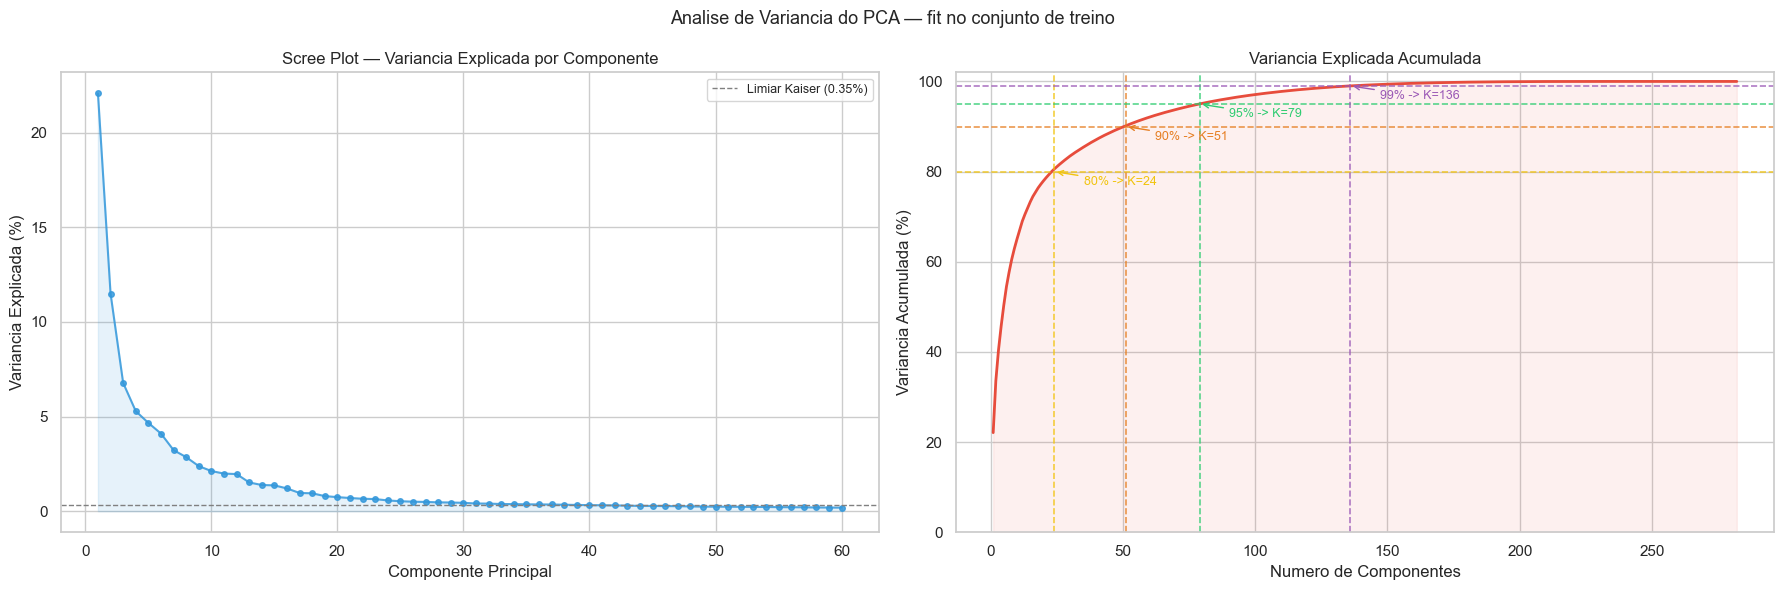

In [53]:
# Scree Plot

n_visual   = min(60, len(feature_cols))
cores_lim  = ['#f1c40f', '#e67e22', '#2ecc71', '#9b59b6']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Scree Plot
ax1.plot(range(1, n_visual + 1), exp_var[:n_visual],
         'o-', color='#3498db', alpha=0.85, markersize=4, lw=1.5)
ax1.axhline(kaiser_threshold, color='gray', ls='--', lw=1,
            label=f'Limiar Kaiser ({kaiser_threshold:.2f}%)')
ax1.fill_between(range(1, n_visual + 1), exp_var[:n_visual], alpha=0.12, color='#3498db')
ax1.set_title('Scree Plot — Variancia Explicada por Componente', fontsize=12)
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Variancia Explicada (%)')
ax1.legend(fontsize=9)

# Variancia Acumulada
ax2.plot(range(1, len(cum_var) + 1), cum_var, '-', color='#e74c3c', lw=2)
ax2.fill_between(range(1, len(cum_var) + 1), cum_var, alpha=0.08, color='#e74c3c')

for lim, cor in zip(limiares, cores_lim):
    k = cortes_k[lim]
    ax2.axhline(lim, color=cor, ls='--', lw=1.2, alpha=0.8)
    ax2.axvline(k,   color=cor, ls='--', lw=1.2, alpha=0.8)
    offset_x = len(feature_cols) * 0.04
    ax2.annotate(f'{lim}% -> K={k}',
                 xy=(k, lim), xytext=(k + offset_x, lim - 3),
                 fontsize=9, color=cor,
                 arrowprops=dict(arrowstyle='->', color=cor, lw=1))

ax2.set_title('Variancia Explicada Acumulada', fontsize=12)
ax2.set_xlabel('Numero de Componentes')
ax2.set_ylabel('Variancia Acumulada (%)')
ax2.set_ylim(0, 102)

plt.suptitle('Analise de Variancia do PCA — fit no conjunto de treino', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'pca_variancia.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 2.3 — Scree Plot e Variância Acumulada:**

- **Localização do cotovelo:** observa-se um cotovelo bem definido entre K ≈ 10 e K ≈ 20. Até esse intervalo, a queda de variância explicada por componente ainda é significativa; a partir daí, o decaimento torna-se claramente mais suave, indicando que os componentes adicionais passam a capturar variações de menor relevância (possivelmente ruído ou variações muito específicas). O fato de 95% da variância só ser atingido em K = 79 sugere que há uma “cauda longa” de componentes com contribuição pequena individualmente, mas coletivamente não desprezável. Isso levanta uma discussão válida: embora o critério de 95% seja conservador, ele pode estar preservando componentes de baixo valor informacional prático. Um corte mais agressivo (por exemplo, entre 30 e 60 componentes) pode ser plausível e deve ser avaliado empiricamente no desempenho do modelo.

- **Comparação Kaiser vs. 95%:** o critério de Kaiser (37 componentes) fornece uma estimativa mais compacta da dimensionalidade relevante, enquanto o critério de 95% (79 componentes) é substancialmente mais conservador. Essa divergência é esperada em datasets com redundância parcial: Kaiser retém apenas componentes com variância acima da média, enquanto o critério de variância acumulada preserva também contribuições mais sutis. Neste contexto, o critério de 95% é adotado como referência por garantir maior preservação de informação, ainda que à custa de menor compressão. A escolha final do número de componentes deve equilibrar esses dois aspectos — compactação e retenção de variância — e será refletida diretamente no desempenho dos modelos nesta etapa.

- **Primeiro componente:** o PC1 concentra uma parcela expressiva da variância (~22.1%), indicando a presença de uma dimensão dominante no dataset. Isso é consistente com a natureza das features extraídas, onde medidas de amplitude global (RMS, potência total, energia wavelet) tendem a ser fortemente correlacionadas entre si. Os componentes seguintes apresentam quedas progressivas (~11.5%, ~6.8%, ~5.2%), sugerindo que, após a dimensão principal, a variabilidade se distribui em múltiplas direções menos dominantes, possivelmente relacionadas a aspectos mais específicos: morfologia, frequência e dinâmica não-linear.

- **Percentual de compressão obtido:** atingir 95% da variância com 79 componentes representa uma compressão de ~72%, o que é um resultado bastante favorável. Isso indica que o dataset possui redundância estrutural significativa — múltiplas features carregam informações sobrepostas que podem ser sintetizadas em um número menor de dimensões. Essa compressão é benéfica por três razões principais: (i) reduz o custo computacional dos modelos, (ii) diminui o risco de overfitting ao eliminar redundâncias, e (iii) melhora a estabilidade numérica de algoritmos sensíveis à dimensionalidade. Ao mesmo tempo, o fato de ainda serem necessários ~80 componentes para preservar 95% da variância reforça que o dataset mantém diversidade informacional relevante, o que é desejável para tarefas de classificação complexas.

### 2.4 Análise dos Loadings — Interpretação Fisiológica dos Componentes

Os *loadings* correspondem aos coeficientes que definem cada componente principal como uma combinação linear das features originais. A análise desses coeficientes permite interpretar, de forma direta, quais aspectos da fisiologia cardíaca estão sendo capturados por cada componente — tornando esta uma das etapas mais relevantes do ponto de vista clínico dentro do PCA.

Em termos práticos, um loading de alta magnitude indica forte contribuição da feature para aquele componente: valores positivos refletem variação na mesma direção do componente, enquanto valores negativos indicam contribuição em sentido oposto. Assim, cada componente pode ser entendido como um eixo latente que combina diferentes características do sinal de ECG.

Para facilitar a interpretação, selecionamos as 40 features com maior influência entre os primeiros 10 componentes principais. Essa seleção é feita com base no maior valor absoluto de loading que cada feature apresenta em qualquer um desses componentes, priorizando aquelas que desempenham papel dominante na definição de pelo menos um dos eixos principais. Dessa forma, o heatmap resultante destaca as variáveis mais relevantes para a estrutura do espaço transformado.

A visualização dos loadings em forma de heatmap permite identificar padrões de agrupamento entre features e componentes, evidenciando quais domínios (temporal, espectral, morfológico, não-linear, etc.) contribuem conjuntamente para a variabilidade dos dados. Essa análise é fundamental para conectar a redução de dimensionalidade com interpretações fisiológicas significativas.

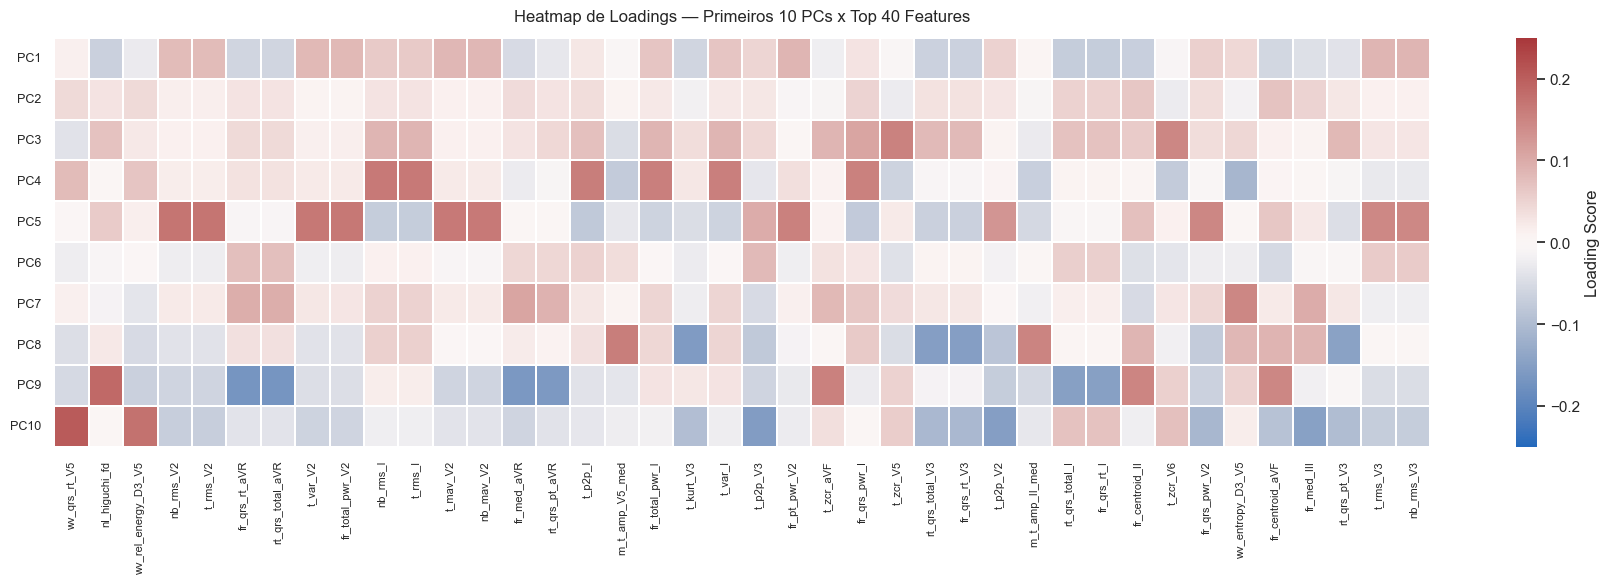

Top 10 features por loading absoluto — PC1 a PC5:
-----------------------------------------------------------------
PC1 (22.1% var): time_mav_III (+0.093), norm_baseline_mav_III (+0.093), time_mav_aVF (+0.091), norm_baseline_mav_aVF (+0.091), norm_baseline_mav_V3 (+0.091)
PC2 (11.5% var): morph_r_amp_II_median (+0.138), freq_qrs_power_aVL (+0.137), freq_qrs_power_II (+0.136), morph_r_amp_V5_median (+0.134), delta_amp_II_aVL (+0.133)
PC3 (6.8% var): time_zcr_V5 (+0.153), time_zcr_V6 (+0.148), time_zcr_V4 (+0.144), freq_qrs_power_aVR (+0.134), time_zcr_V3 (+0.125)
PC4 (5.3% var): norm_baseline_rms_I (+0.166), time_rms_I (+0.166), time_p2p_I (+0.160), freq_total_power_I (+0.158), time_var_I (+0.157)
PC5 (4.7% var): time_rms_V2 (+0.171), norm_baseline_rms_V2 (+0.171), time_var_V2 (+0.168), freq_total_power_V2 (+0.167), time_mav_V2 (+0.165)
PC6 (4.1% var): time_p2p_V5 (+0.142), time_p2p_V4 (+0.136), wavelet_energy_D2_V5 (+0.132), freq_qrs_power_aVF (-0.130), freq_qrs_power_V4 (+0.130)
PC7 (

In [54]:
# Análise dos loadings

loadings    = pca_full.components_[:10, :]
abs_load    = np.abs(loadings)
max_weights = abs_load.max(axis=0)

top40_idx  = max_weights.argsort()[-40:][::-1]
feat_top40 = [feature_cols[i] for i in top40_idx]
load_top40 = loadings[:, top40_idx]

labels_abbr = [f.replace('_median','_med').replace('_power','_pwr')
                .replace('wavelet_','wv_').replace('nonlin_','nl_')
                .replace('freq_','fr_').replace('time_','t_')
                .replace('morph_','m_').replace('hrv_','h_')
                .replace('ratio_','rt_').replace('norm_baseline_','nb_')
               for f in feat_top40]

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(load_top40, cmap='vlag', center=0, vmin=-0.25, vmax=0.25,
            yticklabels=[f'PC{i+1}' for i in range(10)],
            xticklabels=labels_abbr,
            cbar_kws={'label': 'Loading Score'},
            linewidths=0.1, ax=ax)
ax.set_title('Heatmap de Loadings — Primeiros 10 PCs x Top 40 Features', fontsize=12, pad=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'pca_loadings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features por loading absoluto — PC1 a PC5:')
print('-' * 65)
for i in range(10):
    idx5  = np.abs(loadings[i]).argsort()[-5:][::-1]
    itens = ', '.join([f'{feature_cols[j]} ({loadings[i][j]:+.3f})' for j in idx5])
    print(f'PC{i+1} ({exp_var[i]:.1f}% var): {itens}')

**Comentários sobre a subseção 2.4 — Loadings dos Componentes:**

- **PC1 — dimensão de amplitude geral:** o padrão observado confirma claramente essa interpretação. As maiores contribuições vêm de `time_mav_*` e suas versões `norm_baseline_*` em derivações inferiores (III, aVF) e precordiais (V3), todas com sinais positivos e magnitudes muito próximas. Isso indica que o componente captura uma variação global de energia/amplitude do sinal, praticamente independente da derivação específica. A redundância entre versões normalizadas e não normalizadas reforça que o PCA está agregando essas medidas em uma única direção dominante. Como esperado, trata-se de uma dimensão estrutural forte, mas com utilidade diagnóstica limitada isoladamente.

- **PC2 e PC3 — dimensões de contraste morfológico:** aqui já surgem padrões mais informativos. O PC2 combina amplitude de onda R (`morph_r_amp_*`) com potência espectral do QRS (`freq_qrs_power_*`) e uma feature derivada (`delta_amp_II_aVL`), sugerindo um eixo relacionado à intensidade e distribuição do complexo QRS entre derivações. Já o PC3 é dominado por `time_zcr_*` em derivações precordiais (V3–V6), indicando sensibilidade à frequência de cruzamentos por zero — uma proxy de complexidade/fragmentação do sinal. Embora não haja inversões de sinal muito fortes entre grupos de derivações, há uma clara separação de domínios (amplitude vs. dinâmica), o que sugere que esses componentes capturam contrastes morfológicos relevantes, ainda que não diretamente alinhados a um eixo elétrico clássico.

- **PCs de HRV e não-linearidade:** essas features aparecem apenas em componentes mais altos, com destaque para o `nonlin_higuchi_fd` dominando o PC9. Isso indica que a variabilidade de ritmo e a complexidade fractal do sinal representam dimensões de menor variância global. No entanto, isso não implica baixa relevância clínica — apenas que essas variações são mais sutis quando comparadas à amplitude e morfologia do QRS. Esse comportamento ilustra bem a limitação do PCA: componentes com baixa variância explicada ainda podem ser altamente discriminativos, especialmente em tarefas de classificação.

- **Features derivadas:** observa-se que muitas features derivadas aparecem fortemente associadas às suas contrapartes originais nos mesmos componentes. Por exemplo, `delta_amp_II_aVL` aparece junto de `morph_r_amp_II_median` no PC2, e diversas razões espectrais (`ratio_qrs_*`, `freq_qrs_ratio_*`) surgem agrupadas com potências espectrais no PC8–PC10. Isso sugere que, em muitos casos, o PCA absorve essas transformações dentro das mesmas direções latentes — indicando redundância parcial. Por outro lado, algumas combinações (como razões e entropias wavelet nos PCs mais altos) aparecem em componentes distintos, sugerindo que parte das features derivadas contribui com informação complementar não capturada diretamente pelas features originais.

### 2.5 Projeção 2D com Elipses de Confiança

Projetar os dados nos primeiros componentes principais permite avaliar, de forma visual, se as classes formam agrupamentos coerentes em um espaço de menor dimensão. Aqui utilizamos pares de componentes (PC1–PC2, PC1–PC3 e PC2–PC3), que concentram a maior parte da variância do dataset.

Cada ponto representa um exame projetado nesse espaço, enquanto as **elipses de confiança** resumem a distribuição de cada classe.

As elipses são construídas a partir da **matriz de covariância bidimensional** dos pontos de cada classe e possuem três propriedades importantes:

- **Centro da elipse:** média dos pontos da classe no plano (posição média do grupo)
- **Eixos da elipse:** definidos pela variância ao longo das direções principais (autovalores da covariância)
- **Orientação:** determinada pelos autovetores (direções de maior e menor dispersão)

Utilizamos elipses de **1 desvio padrão (≈68% dos dados)**, o que permite observar:

- **Separação entre classes:** elipses bem separadas indicam boa discriminabilidade
- **Sobreposição:** indica regiões onde as classes são difíceis de distinguir
- **Formato da elipse:** revela anisotropia — ou seja, direções preferenciais de variação no espaço PCA

Essa análise não mede desempenho de classificação, mas fornece uma visão qualitativa importante sobre a estrutura do espaço de features após a redução de dimensionalidade.

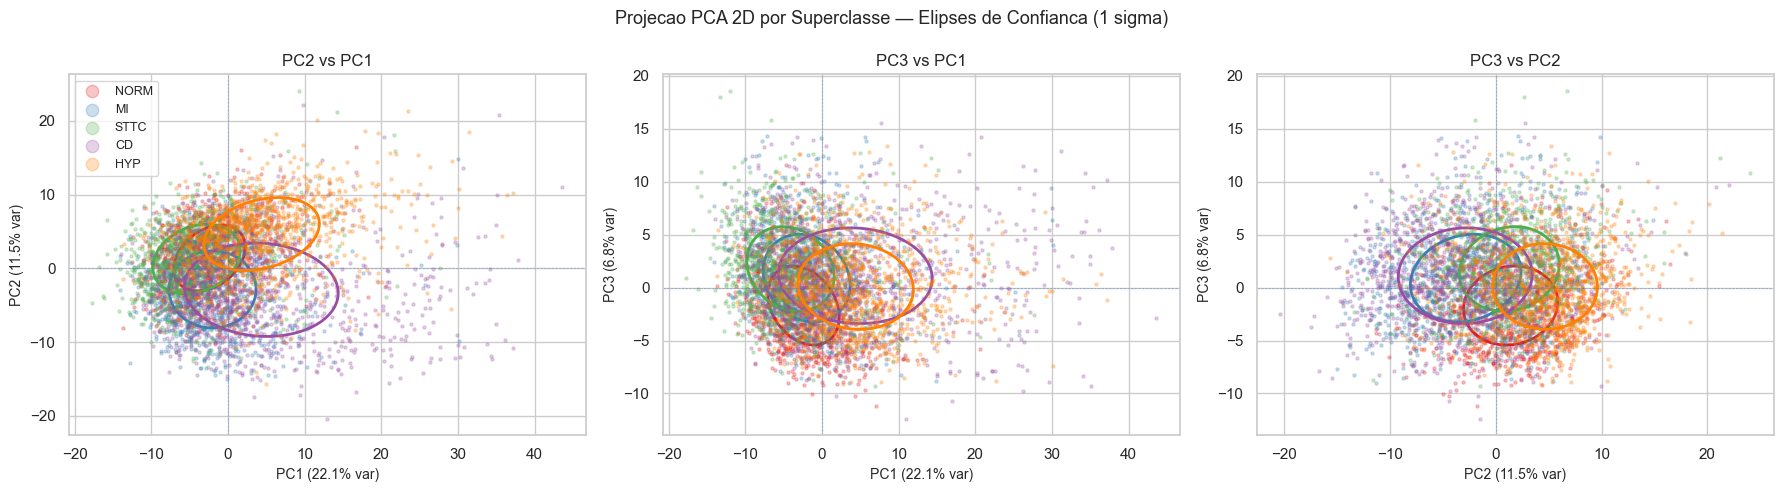

In [55]:
# Cálculo e plot das Elipses de Confiança

def confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):
    if len(x) < 3:
        return

    cov = np.cov(x, y)
    mean_x, mean_y = np.mean(x), np.mean(y)

    # Autovalores e autovetores
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Ordena do maior para o menor
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Ângulo da elipse (graus)
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    # Escala dos eixos
    width  = 2 * n_std * np.sqrt(eigvals[0])
    height = 2 * n_std * np.sqrt(eigvals[1])

    ellipse = Ellipse(
        (mean_x, mean_y),
        width=width,
        height=height,
        angle=angle,
        facecolor=facecolor,
        **kwargs
    )

    return ax.add_patch(ellipse)

pca_top3   = pca_full.transform(X_todos_std)[:, :3]
classes_ok = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
palette    = sns.color_palette('Set1', len(classes_ok))
color_map  = dict(zip(classes_ok, palette))

df_proj = df[['primary_class']].copy()
df_proj['PC1'] = pca_top3[:, 0]
df_proj['PC2'] = pca_top3[:, 1]
df_proj['PC3'] = pca_top3[:, 2]
df_proj = df_proj[df_proj['primary_class'].isin(classes_ok)]

pares = [('PC1', 'PC2'), ('PC1', 'PC3'), ('PC2', 'PC3')]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (pc_x, pc_y) in zip(axes, pares):
    for cls in classes_ok:
        mask_c = df_proj['primary_class'] == cls
        pts = df_proj[mask_c].sample(min(1000, mask_c.sum()), random_state=42)

        ax.scatter(
            pts[pc_x], pts[pc_y],
            s=5, alpha=0.25,
            color=color_map[cls],
            label=cls,
            rasterized=True
        )

        try:
            confidence_ellipse(
                pts[pc_x].values,
                pts[pc_y].values,
                ax,
                n_std=1,
                edgecolor=color_map[cls],
                lw=2
            )
        except Exception:
            pass

    # Guias visuais úteis (mantém leve)
    ax.axhline(0, lw=0.5, linestyle='--', alpha=0.5)
    ax.axvline(0, lw=0.5, linestyle='--', alpha=0.5)

    pc_x_idx = int(pc_x[2:]) - 1
    pc_y_idx = int(pc_y[2:]) - 1

    ax.set_xlabel(f'{pc_x} ({exp_var[pc_x_idx]:.1f}% var)', fontsize=10)
    ax.set_ylabel(f'{pc_y} ({exp_var[pc_y_idx]:.1f}% var)', fontsize=10)
    ax.set_title(f'{pc_y} vs {pc_x}')
    ax.set_title(f'{pc_y} vs {pc_x}')

axes[0].legend(markerscale=4, fontsize=9, loc='best')
plt.suptitle('Projecao PCA 2D por Superclasse — Elipses de Confianca (1 sigma)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'pca_projecao_2d.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 2.5 — Projeção 2D com Elipses de Confiança:**

- **Sobreposição das elipses:** observa-se uma sobreposição significativa entre todas as classes nos três planos analisados, sendo mais acentuada no plano **PC1–PC3**. Esse comportamento é esperado: as superclasses do dataset representam condições fisiopatológicas contínuas, não categorias discretas. A ausência de fronteiras claras indica que o problema não é linearmente separável em baixa dimensão, reforçando a necessidade de modelos mais expressivos no espaço original ou em PCA de maior dimensionalidade.

- **Separação parcial entre classes:** apesar da sobreposição global, há padrões estruturais relevantes. A classe **HYP** apresenta deslocamento consistente para valores positivos de **PC2**, sugerindo associação com dimensões relacionadas à energia/amplitude do sinal — coerente com hipertrofia ventricular. Já **CD** apresenta maior dispersão e leve deslocamento em direções associadas a **PC1/PC3**, possivelmente refletindo variabilidade morfológica e espectral típica de distúrbios de condução. As demais classes (**NORM**, **MI**, **STTC**) permanecem mais concentradas próximas ao centro, com separação mais sutil.

- **Comparação entre os planos:** o plano **PC1–PC2** apresenta uma separação ligeiramente melhor entre as classes em relação ao **PC1–PC3**, que mostra maior sobreposição — indicando que **PC3 adiciona menos capacidade discriminativa nesse contexto**. O plano **PC2–PC3** oferece uma separação intermediária, sugerindo que componentes além de PC1 capturam variações mais específicas, mas ainda insuficientes para discriminação clara em baixa dimensão.

- **Formato e orientação das elipses:** as elipses apresentam formatos alongados e orientações distintas, indicando direções preferenciais de variabilidade no espaço PCA. Isso evidencia que a estrutura dos dados é anisotrópica, com diferentes fatores fisiológicos (amplitude, morfologia, espectro) contribuindo de forma não uniforme para a variância.

- **Implicação para o classificador:** a forte sobreposição no espaço de baixa dimensão indica que classificadores lineares (como LDA ou regressão logística) terão capacidade limitada nesse espaço reduzido. No entanto, como o PCA com **K = 95% (79 componentes)** retém muito mais informação do que os três primeiros PCs, espera-se que a separabilidade seja significativamente maior no espaço completo utilizado pelos modelos.

- **Síntese:** os gráficos indicam que os primeiros componentes capturam principalmente variação global e estrutural ampla, enquanto a informação discriminativa está distribuída em componentes adicionais. Isso reforça a necessidade de abordagens multivariadas para capturar a complexidade do problema.

### 2.6 Modelo PCA Final e Validação por Reconstrução

Nesta etapa, definimos o modelo PCA final a partir de uma **avaliação comparativa entre diferentes níveis de compressão**. Em vez de assumir diretamente um valor de K, testamos configurações representativas (as percebidas na subseção 2.3 por: Análise Visual do Cotovelo: corte mais agressivo; Critério de Kaiser: intermediário e baseados em variância acumulada) e analisamos seu impacto na reconstrução dos dados.

A métrica utilizada é o **erro médio quadrático de reconstrução (RMSE)**, obtido ao aplicar a transformação inversa do PCA. Esse erro quantifica diretamente a perda de informação introduzida pela redução de dimensionalidade.

A partir dessa análise, selecionamos o valor de K que melhor equilibra:

* **compressão** (redução do número de dimensões);
* **fidelidade** (capacidade de reconstruir os dados originais).

Uma vez definido o modelo PCA final, realizamos a **validação por reconstrução**, conforme previsto no pipeline. Nessa etapa, o RMSE é analisado em nível de registro e agregado por:

* **superclasse diagnóstica**;
* **split** (treino, validação e teste).

O objetivo é verificar se a compressão:

* preserva a estrutura global dos dados;
* mantém consistência entre os diferentes subconjuntos;
* e não introduz viés sistemático entre classes.

Essa validação garante que a representação em espaço reduzido seja adequada para as etapas subsequentes de modelagem.


In [56]:
# Análise de "níveis de PCA": busca pelo melhor valor de K descoberto anteriormente
#  
for k_test in [20, 37, k_95]:
    pca_tmp = PCA(n_components=k_test, random_state=42)
    pca_tmp.fit(X_treino_std)
    X_tmp = pca_tmp.transform(X_todos_std)
    X_rec = pca_tmp.inverse_transform(X_tmp)
    
    rmse = np.sqrt(np.mean((X_todos_std - X_rec) ** 2))
    print(f'K={k_test:3d} -> RMSE={rmse:.4f}')

K= 20 -> RMSE=0.4677
K= 37 -> RMSE=0.3716
K= 79 -> RMSE=0.2227


**Definição do número de componentes (K) — análise baseada em erro de reconstrução:**

Para avaliar o impacto da escolha de K na preservação da informação, comparamos o erro médio de reconstrução (RMSE) para três configurações representativas:

- **K = 20** (aproximação do cotovelo): RMSE = 0.4677  
- **K = 37** (critério de Kaiser): RMSE = 0.3716  
- **K = 79** (variância acumulada ≥ 95%): RMSE = 0.2227  

Observa-se uma **redução consistente e significativa do erro** à medida que K aumenta. Em particular:

- A transição de **K = 20 → 37** reduz o erro, mas ainda mantém perda relevante de informação.
- A transição de **K = 37 → 79** produz uma **queda expressiva adicional (~40%) no RMSE**, indicando que uma parcela importante da variância está distribuída em componentes além da dimensionalidade “estrutural” sugerida por Kaiser.

Esse comportamento confirma que, embora o dataset possua uma estrutura dominante de baixa dimensão, existe **informação relevante em componentes de menor magnitude**, que impacta diretamente a fidelidade da reconstrução.

Dessa forma, opta-se por utilizar **K = 79 (95% de variância acumulada)** no modelo PCA final. Essa escolha privilegia a preservação de informação e reduz significativamente o erro de reconstrução, sendo mais adequada para o objetivo de classificação, onde perdas sutis podem comprometer a separabilidade entre classes.

Os resultados de RMSE por classe e por split apresentados a seguir complementam essa análise, verificando se essa compressão é consistente e não introduz viés entre superclasses.

In [57]:
# Modelo PCA Final

k_95 = cortes_k[95]
print(f'Instanciando PCA final com K = {k_95} componentes (>= 95% da variancia)...')

pca_final = PCA(n_components=k_95, random_state=42)
pca_final.fit(X_treino_std)

X_todos_pca = pca_final.transform(X_todos_std)

cols_pca = [f'PC{i+1}' for i in range(k_95)]
df_pca   = df[META_COLS].copy()
df_pca[cols_pca] = X_todos_pca

print(f'Dataset PCA gerado : {df_pca.shape}')
print(f'Variancia retida   : {pca_final.explained_variance_ratio_.sum()*100:.2f}%')

Instanciando PCA final com K = 79 componentes (>= 95% da variancia)...
Dataset PCA gerado : (17744, 86)
Variancia retida   : 95.01%


In [58]:
# Reconstrucao: inverse_transform e calculo do RMSE por registro

X_reconstruido = pca_final.inverse_transform(X_todos_pca)

# RMSE calculado no espaço padronizado — usado apenas para comparação relativa
rmse_por_reg   = np.sqrt(np.mean((X_todos_std - X_reconstruido) ** 2, axis=1))

df_rec = df[['primary_class', 'strat_fold']].copy()
df_rec['rmse'] = rmse_por_reg

classes_target = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

print(f'RMSE medio global de reconstrucao : {rmse_por_reg.mean():.4f}  (espaco padronizado)')
print()
print('RMSE de Reconstrucao por Superclasse:')
display(
    df_rec[df_rec['primary_class'].isin(classes_target)]
    .groupby('primary_class')['rmse']
    .agg(['mean', 'median', 'std'])
    .round(4)
    .rename(columns={'mean': 'Media', 'median': 'Mediana', 'std': 'Desvio Padrao'})
)

split_map = {**{f: 'Treino' for f in FOLDS_TREINO},
             FOLD_VAL: 'Validacao', FOLD_TEST: 'Teste'}
df_rec['split'] = df_rec['strat_fold'].map(split_map)
print('\nRMSE medio por split:')
display(df_rec.groupby('split')['rmse'].mean().round(4).to_frame('RMSE Medio'))

RMSE medio global de reconstrucao : 0.2091  (espaco padronizado)

RMSE de Reconstrucao por Superclasse:


,Media,Mediana,Desvio Padrao
primary_class,,,
CD,0.2436,0.2285,0.0812
HYP,0.2258,0.2132,0.0629
MI,0.2255,0.2123,0.0752
NORM,0.1733,0.1652,0.0463
STTC,0.2091,0.1996,0.0543



RMSE medio por split:


,RMSE Medio
split,
Teste,0.2087
Treino,0.2092
Validacao,0.2085


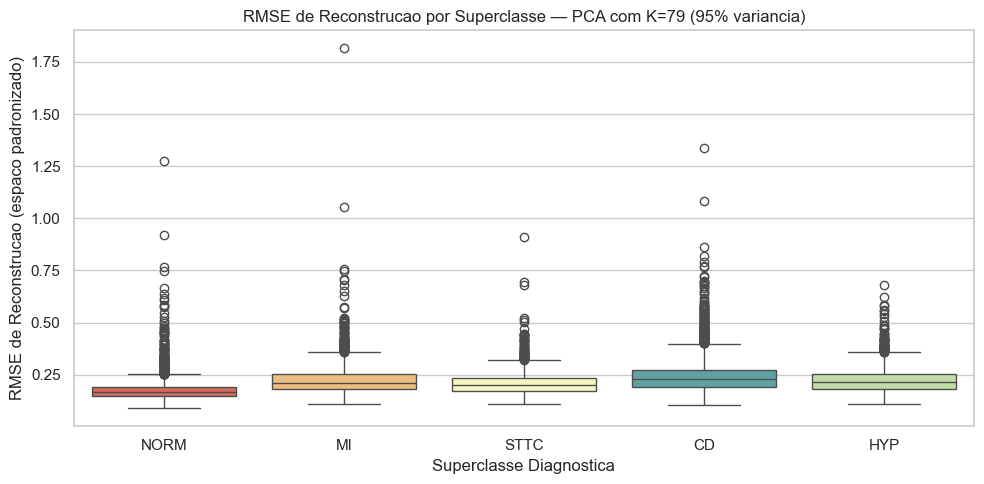

In [59]:
# Box plot dos resultados

fig, ax = plt.subplots(figsize=(10, 5))
df_box = df_rec[df_rec['primary_class'].isin(classes_target)]
sns.boxplot(data=df_box, x='primary_class', y='rmse',
            order=classes_target, hue='primary_class',
            palette='Spectral', legend=False, ax=ax)
ax.set_title(f'RMSE de Reconstrucao por Superclasse — PCA com K={k_95} (95% variancia)', fontsize=12)
ax.set_xlabel('Superclasse Diagnostica')
ax.set_ylabel('RMSE de Reconstrucao (espaco padronizado)')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'pca_rmse_reconstrucao.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# Gera resumo tipo "boxplot" em markdown (para facilitar visualização numérica dos valores do boxplot acima)

classes_order = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

df_box = df_rec[df_rec['primary_class'].isin(classes_order)]

print("| class | median | q25 | q75 | iqr | mean |")
print("|---|---|---|---|---|---|")

for cls in classes_order:
    vals = df_box.loc[df_box['primary_class'] == cls, 'rmse'].dropna()
    
    if len(vals) == 0:
        continue
    
    q25   = vals.quantile(0.25)
    med   = vals.quantile(0.50)
    q75   = vals.quantile(0.75)
    iqr   = q75 - q25
    mean  = vals.mean()
    
    print(f"| {cls} | {med:.4f} | {q25:.4f} | {q75:.4f} | {iqr:.4f} | {mean:.4f} |")

| class | median | q25 | q75 | iqr | mean |
|---|---|---|---|---|---|
| NORM | 0.1652 | 0.1467 | 0.1892 | 0.0425 | 0.1733 |
| MI | 0.2123 | 0.1809 | 0.2530 | 0.0721 | 0.2255 |
| STTC | 0.1996 | 0.1739 | 0.2323 | 0.0585 | 0.2091 |
| CD | 0.2285 | 0.1907 | 0.2749 | 0.0842 | 0.2436 |
| HYP | 0.2132 | 0.1831 | 0.2530 | 0.0700 | 0.2258 |


**Comentários sobre a subseção 2.6 — Validação por Reconstrução:**

* **Magnitude do RMSE global:** o RMSE médio observado (~0,21) no espaço padronizado indica que, em média, cada feature é reconstruída com erro de aproximadamente 0,21 desvios padrão. Esse valor está **bem dentro do esperado** para um cenário com ~72% de compressão (K = 79), sugerindo que a maior parte da estrutura dos dados foi preservada. Não há indício de perda severa de informação — valores críticos (>0,30) não foram atingidos, o que valida a escolha do corte de 95% sem necessidade imediata de expandir para 99%.

* **Diferença de RMSE entre classes:** há variação moderada entre as classes, com **CD apresentando o maior erro médio (≈0,24)** e **NORM o menor (≈0,17)**. Esse padrão faz sentido: sinais normais tendem a ser mais homogêneos e, portanto, mais fáceis de reconstruir com poucos componentes. Já CD, que envolve alterações de condução e maior variabilidade morfológica, exige mais componentes para representação fiel. Importante notar que **HYP não apresenta erro desproporcionalmente alto**, o que indica que suas características estruturais relevantes estão bem capturadas dentro dos 95% de variância retida. No geral, não há evidência de viés crítico contra nenhuma classe.

* **Dispersão intra-classe (IQR e desvio):** classes como **CD e MI apresentam maior IQR e desvio padrão**, indicando heterogeneidade interna — diferentes padrões fisiopatológicos sendo comprimidos em uma mesma representação. Isso sugere que, embora o PCA preserve bem a estrutura global, existem subgrupos internos cuja reconstrução é mais desafiadora. Esse comportamento é esperado em bases clínicas reais.

* **RMSE treino vs. teste:** os valores são praticamente idênticos (≈0,209 em todos os splits), o que indica **alta estabilidade e ausência de overfitting**. O PCA, sendo um método linear e não supervisionado, raramente overfita, e esse resultado confirma que a estrutura aprendida no treino generaliza bem para validação e teste.

* **Leitura geral:** a combinação de **RMSE baixo, estabilidade entre splits e ausência de viés entre classes** indica que o PCA com K = 79 produz uma representação comprimida confiável. A leve variação entre classes reflete diferenças reais de complexidade fisiológica, e não falhas do modelo. Isso valida o uso desse espaço reduzido como entrada para os modelos de classificação no pipeline.


---

## Seção 3 — ICA (Independent Component Analysis)

### 3.1 Fundamentação

Enquanto o PCA encontra direções de máxima **variância** com restrição de ortogonalidade, o ICA busca componentes com máxima **independência estatística** — uma condição mais forte que a mera descorrelação. Dois sinais descorrelacionados podem ainda ter dependências de ordem superior (ex: um pode modular a variância do outro); componentes independentes não têm nenhum tipo de dependência estatística entre si.

O ICA é baseado na **suposição de não-gaussianidade das fontes**: pelo Teorema Central do Limite, uma mistura linear de sinais independentes tende a ser mais gaussiana que as fontes originais. O algoritmo **FastICA** (Hyvärinen & Oja, 2000) maximiza a **neguentropia** (conceito que representa o grau de organização, ordem e previsibilidade em um sistema, contrapondo-se à entropia, que é a tendência natural ao caos e à desordem) de cada componente usando funções de contraste — eficiente e numericamente estável para dados de baixa a média dimensão.

**Por que aplicar ICA sobre os componentes PCA e não diretamente nas features?**

O FastICA tem dificuldade de convergir em espaços de alta dimensão com features altamente correlacionadas. A estratégia padrão é aplicá-lo sobre os primeiros $k$ componentes PCA, que já são descorrelacionados e compactam a estrutura de maior variância. O ICA então "rotaciona" esse espaço comprimido buscando independência estatística.

**Objetivo desta análise:** investigar quais componentes independentes capturam variações **estatisticamente relevantes e potencialmente discriminativas** entre as classes diagnósticas. Para isso, avaliamos cada IC sob duas perspectivas complementares: (i) sua capacidade de separação entre classes, medida via **ANOVA (F-score)**, e (ii) seu grau de **não-gaussianidade**, quantificado por métricas como kurtosis e skewness. Componentes com alta discriminabilidade e forte não-gaussianidade são interpretados como mais informativos, enquanto componentes aproximadamente gaussianos tendem a refletir variações mais simples ou redundantes do espaço PCA.


### 3.2 Ajuste do FastICA

Nesta etapa, aplicamos o algoritmo FastICA sobre os primeiros componentes principais obtidos pelo PCA. O número de componentes independentes é definido como ( n_{\text{ica}} = \min(20, k_{95}) ), limitando a análise a um subconjunto das direções de maior variância e garantindo estabilidade numérica do algoritmo.

O modelo é ajustado apenas no conjunto de treino, sendo posteriormente aplicado a todo o dataset. O resultado é uma nova representação dos dados em termos de componentes independentes (ICs), armazenados no DataFrame `df_ica`.

A convergência do algoritmo é monitorada pelo número de iterações realizadas. Caso o limite máximo seja atingido, isso pode indicar dificuldade na separação das fontes — geralmente associada a baixa não-gaussianidade ou redundância residual entre componentes.


In [61]:
# Cálculo dos componentes ICs

n_ica = min(20, k_95)

print(f'Ajustando FastICA com {n_ica} componentes sobre os primeiros {n_ica} PCs...')

X_treino_pca = pca_final.transform(X_treino_std)[:, :n_ica]
X_todos_ica_in = X_todos_pca[:, :n_ica]

ica = FastICA(n_components=n_ica, random_state=42, max_iter=1000, tol=1e-4)
ica.fit(X_treino_pca)

X_todos_ica = ica.transform(X_todos_ica_in)

cols_ica = [f'IC{i+1}' for i in range(n_ica)]
df_ica   = pd.DataFrame(X_todos_ica, columns=cols_ica, index=df.index)

print(f'Matriz ICA calculada : {df_ica.shape}')
print(f'Iteracoes FastICA    : {ica.n_iter_}')
if ica.n_iter_ >= 1000:
    print('Aviso: FastICA atingiu o limite de iteracoes — resultados podem ser imprecisos.')
    print('Considere aumentar max_iter ou checar a gaussianidade das features.')

Ajustando FastICA com 20 componentes sobre os primeiros 20 PCs...
Matriz ICA calculada : (17744, 20)
Iteracoes FastICA    : 51


### 3.3 Análise dos Componentes Independentes — Discriminabilidade e Não-Gaussianidade

Nesta etapa, avaliamos os componentes independentes sob duas perspectivas complementares.

Primeiramente, medimos o **poder discriminativo** de cada IC em relação às superclasses diagnósticas utilizando a **ANOVA F-statistic** no conjunto de treino. Essa métrica quantifica o quanto cada componente separa as classes em termos de diferença de médias.

Em seguida, analisamos o grau de **não-gaussianidade** de cada componente por meio das métricas de **kurtosis** e **skewness**, que indicam, respectivamente, a presença de caudas pesadas/outliers e a assimetria da distribuição.

A combinação dessas duas análises permite distinguir entre:

* componentes **altamente informativos e estruturalmente independentes** (alto F-score e alta não-gaussianidade);
* componentes **discriminativos, porém aproximadamente gaussianos**, que tendem a refletir variações mais simples ou redundantes;
* e componentes com **baixa relevância geral**, candidatos a descarte em etapas posteriores.


In [62]:
# ANOVA F-statistic para os ICs (treino)

X_ica = df_ica.loc[mask_treino, cols_ica]
y     = df.loc[mask_treino, 'primary_class']

F_vals, p_vals = f_classif(X_ica, y)

df_anova_ica = (
    pd.DataFrame({
        'IC': cols_ica,
        'F_score': F_vals,
        'p_value': p_vals
    })
    .sort_values('F_score', ascending=False)
    .reset_index(drop=True)
)

print('Valores de ICs por poder discriminativo (ANOVA F-statistic):')
display(df_anova_ica.round(4))

Valores de ICs por poder discriminativo (ANOVA F-statistic):


,IC,F_score,p_value
0,IC4,792.9005,0.0
1,IC5,390.7188,0.0
2,IC9,296.1655,0.0
3,IC18,268.4984,0.0
4,IC10,192.1104,0.0
5,IC19,168.9515,0.0
6,IC12,167.7707,0.0
7,IC1,159.0437,0.0
8,IC3,143.2816,0.0
9,IC11,135.4709,0.0


In [63]:
# Estatísticas de não-gaussianidade dos ICs

stats_ica = []

for col in cols_ica:
    vals = df_ica[col].values
    
    stats_ica.append({
        'IC': col,
        'kurtosis': kurtosis(vals),
        'skewness': skew(vals),
        '|kurtosis|': abs(kurtosis(vals)),
        '|skewness|': abs(skew(vals))
    })

df_stats_ica = (
    pd.DataFrame(stats_ica)
    .sort_values('|kurtosis|', ascending=False)
    .reset_index(drop=True)
)

print('ICs ordenados por |kurtosis| decrescente:')
display(df_stats_ica.round(4))

ICs ordenados por |kurtosis| decrescente:


,IC,kurtosis,skewness,|kurtosis|,|skewness|
0,IC4,24.7879,3.6825,24.7879,3.6825
1,IC19,23.2982,-3.7842,23.2982,3.7842
2,IC7,14.1639,-2.5343,14.1639,2.5343
3,IC8,7.0919,-1.8228,7.0919,1.8228
4,IC16,5.0931,-1.7044,5.0931,1.7044
5,IC9,3.8240,0.9204,3.8240,0.9204
6,IC3,3.1629,0.2065,3.1629,0.2065
7,IC15,2.9170,0.6162,2.9170,0.6162
8,IC1,2.1572,-0.9521,2.1572,0.9521
9,IC11,1.8606,0.6048,1.8606,0.6048


### 3.4 Integração das Métricas — Seleção de Componentes Independentes

Após avaliar separadamente o poder discriminativo (ANOVA) e o grau de não-gaussianidade dos componentes independentes, integramos essas duas perspectivas em uma análise unificada.

O objetivo é identificar quais ICs são **menos informativos no contexto do problema**, combinando dois critérios:

* baixo poder de separação entre classes (baixo F-score);
* baixa não-gaussianidade (distribuição próxima da gaussiana, indicando menor independência estrutural).

Para isso, realizamos o merge das métricas e construímos um **score de descarte**, baseado no ranqueamento crescente de ambas as medidas. Componentes com valores baixos em ambos os critérios tendem a aparecer no topo da lista como candidatos a remoção.

Esse procedimento não elimina automaticamente componentes, mas fornece um **critério orientado por dados** para decisões de redução dimensional no espaço ICA, equilibrando interpretabilidade estatística e relevância para classificação.


In [64]:
# Merge ANOVA + estatísticas de não-gaussianidade

df_ica_analysis = df_anova_ica.merge(df_stats_ica, on='IC')

# Score de descarte: combina baixo F-score + baixa não-gaussianidade
df_ica_analysis['score_descartar'] = (
    df_ica_analysis['F_score'].rank(ascending=True) +
    df_ica_analysis['|kurtosis|'].rank(ascending=True)
)

# Ordena pelos piores candidatos (menor score = pior)
df_ica_analysis = df_ica_analysis.sort_values('score_descartar')

print('ICs mais candidatos a descarte (baixo F + baixa não-gaussianidade):')
display(df_ica_analysis.round(4))

ICs mais candidatos a descarte (baixo F + baixa não-gaussianidade):


,IC,F_score,p_value,kurtosis,skewness,|kurtosis|,|skewness|,score_descartar
18,IC20,35.2104,0.0,0.5441,0.0724,0.5441,0.0724,6.0
16,IC13,57.2754,0.0,0.5993,0.4336,0.5993,0.4336,9.0
19,IC6,23.3034,0.0,1.3218,0.6103,1.3218,0.6103,10.0
11,IC17,118.8072,0.0,-0.3705,0.1156,0.3705,0.1156,11.0
10,IC2,128.8397,0.0,-0.3779,0.0394,0.3779,0.0394,13.0
15,IC14,74.4883,0.0,1.5413,0.6506,1.5413,0.6506,15.0
6,IC12,167.7707,0.0,0.6781,-0.1301,0.6781,0.1301,20.0
1,IC5,390.7188,0.0,-0.2389,-0.0853,0.2389,0.0853,20.0
17,IC8,48.7112,0.0,7.0919,-1.8228,7.0919,1.8228,20.0
12,IC15,102.0498,0.0,2.9170,0.6162,2.9170,0.6162,21.0


**Comentários sobre a subseção 3.4 — Integração das Métricas (Seleção de ICs):**

* **Consistência do ranking:** a combinação entre F-score e kurtosis produziu uma ordenação coerente. Os primeiros ICs apresentam simultaneamente baixo poder discriminativo e baixa não-gaussianidade, caracterizando componentes pouco informativos e próximos de ruído ou variações residuais do espaço PCA.

* **Principais candidatos a descarte:** IC20, IC13 e IC6 aparecem como os piores colocados, com F-scores reduzidos e distribuições próximas da gaussiana. Esses componentes dificilmente contribuem para a separação entre classes e tendem a não carregar estrutura estatística relevante.

* **Casos intermediários:** há componentes com comportamento misto. IC5, por exemplo, apresenta F-score elevado, mas kurtosis muito baixa, indicando que é discriminativo apesar de aproximadamente gaussiano. Já IC8 apresenta alta kurtosis, mas baixo F-score, sugerindo independência estrutural sem utilidade direta para classificação. Isso evidencia que independência e discriminabilidade não são equivalentes.

* **Componentes mais relevantes:** IC4, IC19 e IC9 combinam F-scores elevados com alta não-gaussianidade, sendo os mais alinhados ao objetivo do ICA. Esses componentes capturam estruturas independentes que também diferenciam as classes, representando a informação mais útil no espaço transformado.

* **Distribuição da não-gaussianidade:** a grande variação de kurtosis entre os ICs (de valores próximos de zero até acima de 20) indica que o FastICA conseguiu extrair componentes com diferentes níveis de independência estatística, incluindo direções associadas a eventos raros ou padrões mais complexos.

* **Implicação para o pipeline:** a análise sugere uma estratégia clara de seleção: remover ICs com baixo F-score e baixa não-gaussianidade, manter componentes discriminativos independentemente da forma da distribuição, e priorizar aqueles que combinam ambas as propriedades. Isso resulta em uma redução de dimensionalidade mais alinhada com o objetivo de classificação do que o uso isolado do PCA.


---

## Seção 4 — Persistência dos Artefatos e Síntese

### 4.1 Salvamento

Nesta etapa, consolidamos os principais artefatos gerados ao longo do entregável, garantindo **reprodutibilidade, rastreabilidade e reutilização eficiente** nas etapas posteriores do pipeline.

São persistidos:

* o pipeline completo de transformação (padronização + PCA + ICA), permitindo aplicar exatamente as mesmas operações em novos dados;
* o dataset projetado no espaço PCA, que servirá como entrada para os modelos de classificação;
* a tabela de variância explicada, utilizada tanto para análise quanto para documentação dos resultados.

Essa organização assegura que as decisões tomadas neste entregável possam ser recuperadas e avaliadas de forma consistente nos próximos estágios.

In [65]:
# Pipeline completo serializado para reproducibilidade

# Seleção de ICs candidatos a descarte (top 5 piores)
n_descartar = 5
ics_descartar = df_ica_analysis.head(n_descartar)['IC'].tolist()

# Pipeline completo serializado para reproducibilidade
pipeline_pca = {
    'scaler_pca'  : scaler_pca,
    'pca_model'   : pca_final,
    'ica_model'   : ica,

    # Estrutura PCA
    'k_95'        : k_95,
    'variancia_retida': float(pca_final.explained_variance_ratio_.sum()),

    # Features
    'feature_cols': feature_cols,
    'cols_pca'    : cols_pca,

    # ICA
    'cols_ica'    : cols_ica,
    
    # ---- decisões analíticas ----
    'ica_analysis': {
        'criterio': 'baixo F-score + baixa não-gaussianidade',
        'ics_candidatos_descartar': ics_descartar,
        'n_ica_utilizado': n_ica,
    },

    'pca_analysis': {
        'k_kaiser': 37,
        'k_95': k_95,
        'observacao': 'alta variancia concentrada nos primeiros PCs com cauda longa de variancia difusa'
    }
}

joblib.dump(pipeline_pca, OUT_DIR / 'pca_pipeline.pkl')

# Dataset PCA com metadados
df_pca.to_parquet(OUT_DIR / 'features_pca.parquet', index=True)

# Tabela de variancia por componente — util para reportar no relatorio
df_var = pd.DataFrame({
    'componente'           : [f'PC{i+1}' for i in range(len(exp_var))],
    'variancia_explicada'  : exp_var.round(4),
    'variancia_acumulada'  : cum_var.round(4),
})
df_var.to_csv(OUT_DIR / 'pca_variancia_componentes.csv', index=False)

print('\nArquivos gerados com sucesso:')
print('-' * 55)
print(f'Pipeline completo       : pca_pipeline.pkl')
print(f'  - Componentes PCA     : {k_95}')
print(f'  - Variancia retida    : {pipeline_pca["variancia_retida"]*100:.2f}%')
print(f'  - Componentes ICA     : {n_ica}')
print()
print(f'Dataset PCA             : features_pca.parquet')
print(f'  - Dimensao            : {df_pca.shape[0]} registros × {df_pca.shape[1]} colunas')
print()
print(f'Variancia por componente: pca_variancia_componentes.csv')
print('-' * 55)


Arquivos gerados com sucesso:
-------------------------------------------------------
Pipeline completo       : pca_pipeline.pkl
  - Componentes PCA     : 79
  - Variancia retida    : 95.01%
  - Componentes ICA     : 20

Dataset PCA             : features_pca.parquet
  - Dimensao            : 17744 registros × 86 colunas

Variancia por componente: pca_variancia_componentes.csv
-------------------------------------------------------


### 4.2 Síntese e Conexão com o Entregável 9

#### O que foi feito neste entregável

| Etapa                                         | Resultado                                                               |
| --------------------------------------------- | ----------------------------------------------------------------------- |
| Diagnóstico de dimensionalidade               | Razão F/√N e correlação média entre features calculadas                 |
| StandardScaler (fit treino)                   | Variância unitária por feature para entrada no PCA                      |
| PCA completo — análise de variância           | Scree plot, variância acumulada, cortes por limiar                      |
| Análise de loadings (10 PCs, Top 40 features) | Interpretação fisiológica dos componentes principais                    |
| Projeção 2D com elipses de confiança          | Validação visual da estrutura diagnóstica no espaço PCA                 |
| PCA final K = 95% de variância                | Dataset comprimido `features_pca.parquet`                               |
| Validação por reconstrução                    | RMSE por classe e por split — sem viés diferencial                      |
| FastICA (20 componentes sobre PCA)            | Componentes independentes no espaço reduzido                            |
| Análise dos ICs (ANOVA + não-gaussianidade)   | Identificação de componentes pouco informativos e candidatos a descarte |

---

#### Limitações

* O PCA é uma transformação **linear** — relações não-lineares entre features podem não ser capturadas. Embora técnicas como UMAP ou kernel-PCA consigam modelar essas relações, elas sacrificam interpretabilidade e estabilidade do pipeline, que são requisitos importantes neste contexto.

* O critério de 95% revelou uma **cauda longa de variância distribuída** (K=79 vs. cotovelo ≈ 10–20), indicando que parte da informação está fragmentada em componentes de baixa magnitude. Isso levanta a possibilidade de que estruturas sutis, potencialmente discriminativas, estejam espalhadas fora dos primeiros PCs.

* O RMSE de reconstrução (~0.21 no espaço padronizado) indica boa preservação global da informação, mas diferenças entre classes (ex: CD maior que NORM) sugerem que certos padrões morfológicos mais complexos são menos bem representados.

* O ICA depende da hipótese de **não-gaussianidade** das fontes. Apesar disso, observou-se que alguns ICs apresentam baixa kurtosis, indicando que parte dos componentes extraídos pode não refletir fontes independentes bem definidas, limitando o ganho em relação ao PCA puro.

* A análise de relevância dos ICs foi baseada em métricas **univariadas (F-score)** e estatísticas marginais (kurtosis/skewness), o que não captura interações multivariadas — portanto, a decisão de descarte ainda precisa ser validada empiricamente.

---

#### Próximos passos — Entregável 9

O Entregável 9 (Seleção de Atributos) opera **sobre o `features_engineered.parquet` do Entregável 7**, e não sobre o `features_pca.parquet` deste entregável.

O objetivo será selecionar um subconjunto reduzido de features **originais e interpretáveis**, maximizando a separabilidade diagnóstica por meio de diferentes abordagens:

* **Filter methods:** ANOVA, Mutual Information
* **Wrapper methods:** Sequential Forward Selection
* **Embedded methods:** LASSO

Isso permitirá comparar dois paradigmas distintos:

* compressão baseada em projeção (PCA/ICA);
* seleção direta de atributos originais.

Além disso, os resultados da análise de ICs deste entregável poderão ser utilizados como hipótese experimental no Entregável 9, testando se a remoção de componentes pouco informativos impacta (ou não) o desempenho dos modelos.


In [66]:
# Tabela resumo final

print('=' * 55)
print('   VERIFICACAO FINAL — ENTREGAVEL 8')
print('=' * 55)
print(f'  Features originais (E7)  : {len(feature_cols)}')
print(f'  Componentes PCA (95%)    : {k_95}  ({(1 - k_95/len(feature_cols))*100:.1f}% de compressao)')
print(f'  Variancia retida         : {pca_final.explained_variance_ratio_.sum()*100:.2f}%')
print(f'  RMSE reconstrucao medio  : {rmse_por_reg.mean():.4f}  (espaco padronizado)')
print(f'  ICs calculados (ICA)     : {n_ica}')
print(f'  Convergencia FastICA     : {ica.n_iter_} iteracoes')
print()
print('  Artefatos gerados:')
print('    - features_pca.parquet')
print('    - pca_pipeline.pkl')
print('    - pca_variancia_componentes.csv')
print()
print('  Dataset PCA pronto para o Entregavel de RP.')
print('  Dataset engenhado (E7) segue para o Entregavel 9.')
print('=' * 55)

   VERIFICACAO FINAL — ENTREGAVEL 8
  Features originais (E7)  : 282
  Componentes PCA (95%)    : 79  (72.0% de compressao)
  Variancia retida         : 95.01%
  RMSE reconstrucao medio  : 0.2091  (espaco padronizado)
  ICs calculados (ICA)     : 20
  Convergencia FastICA     : 51 iteracoes

  Artefatos gerados:
    - features_pca.parquet
    - pca_pipeline.pkl
    - pca_variancia_componentes.csv

  Dataset PCA pronto para o Entregavel de RP.
  Dataset engenhado (E7) segue para o Entregavel 9.
